# Sentinel-2 L2A — loading a fetched scene, and the three quirks that produce wrong numbers

**what**  : Loads the scene `aeris dataset fetch` put on disk, through the same loader every later phase
            uses, and plots NDVI from it.
**where** : `notebooks/02_data_exploration/`. Paired with the `sentinel2-l2a` record in
            `app/constants/datasets.py`, whose `quirks` are the one-line version of what is measured here.
**how**   : The roadmap's 1.1 deliverable is "one notebook per dataset that loads it, plots a sample and
            records its quirks". The quirks are the point. Each of the three below produces a plausible
            number rather than an error, which is the only kind of bug worth writing a notebook about.

Run it after:

    uv run aeris dataset fetch sentinel2-l2a --bbox 77.40,28.62,77.50,28.70 \
        --from 2024-03-01 --to 2024-03-31 --max-cloud 10 --asset B04,B08


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import Window

from app.constants.datasets import DatasetId, DatasetSplit
from app.services.datasets.catalogue import inspect_dataset
from app.services.datasets.loader import load_samples

plt.rcParams["figure.figsize"] = (12, 5)


## 1. The loader, not a path

Read through `load_samples` rather than by globbing a directory — the same call Phase 1.6 will make.
A notebook that reaches for the path directly is a notebook that keeps working after the loader breaks.


In [3]:
status = inspect_dataset(DatasetId.SENTINEL2_L2A)
print(f"{status.availability.value}  {status.size_bytes / 1e6:.0f} MB  {status.directory}")

samples = list(load_samples(DatasetId.SENTINEL2_L2A, DatasetSplit.ALL))
scene = samples[0]
print(f"\nscene: {scene.sample_id}")
for band in scene.images:
    print(f"  {band.name:10s} {band.stat().st_size / 1e6:7.1f} MB")

bands = {band.stem: band for band in scene.images}


ready  489 MB  C:\movin\programing\3_projects\aeris\backend\data\datasets\sentinel2-l2a

scene: S2B_MSIL2A_20240319T052649_R105_T43RGM_20240319T094507
  B04.tif      245.7 MB
  B08.tif      242.9 MB


## 2. Quirk one — reflectance is scaled, and offset from baseline 04.00

The stored values are integers, not reflectance. Divide by 10000 to get reflectance, and **subtract the
1000 offset** on scenes processed with baseline 04.00 or later. NDVI is a ratio, so it is *partly*
forgiving of the scale — and not at all forgiving of the offset, which shifts the numerator and
denominator by different relative amounts.

Read a window rather than the whole band: a full 10 m tile is 10980×10980, and reading two of them into
memory is ~480 MB before any arithmetic.


In [3]:
WINDOW = Window(5000, 5000, 1024, 1024)

with rasterio.open(bands["B04"]) as red_source:
    red_raw = red_source.read(1, window=WINDOW).astype("float32")
    profile = red_source.profile
with rasterio.open(bands["B08"]) as nir_source:
    nir_raw = nir_source.read(1, window=WINDOW).astype("float32")

print(f"raw digital numbers   red {red_raw.min():.0f}-{red_raw.max():.0f}   nir {nir_raw.min():.0f}-{nir_raw.max():.0f}")
print(f"crs {profile['crs']}   dtype {profile['dtype']}   nodata {profile['nodata']}")

BOA_OFFSET = 1000.0
BOA_SCALE = 10000.0

red = (red_raw - BOA_OFFSET) / BOA_SCALE
nir = (nir_raw - BOA_OFFSET) / BOA_SCALE
print(f"reflectance           red {red.min():.3f}-{red.max():.3f}   nir {nir.min():.3f}-{nir.max():.3f}")


raw digital numbers   red 1083-6664   nir 1225-6992
crs EPSG:32643   dtype uint16   nodata 0.0
reflectance           red 0.008-0.566   nir 0.023-0.599


### What forgetting the offset actually costs

Both NDVI maps look like NDVI maps. That is the whole problem — there is no error, only a different
answer, and the difference is largest exactly where vegetation is sparse and the decision is marginal.


In [4]:
def ndvi(red_band: np.ndarray, nir_band: np.ndarray) -> np.ndarray:
    """NDVI with a guarded denominator. `np.errstate` rather than `+ 1e-10`: adding an epsilon silently
    turns a division by zero into a very small number, which is a value the histogram then includes."""
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where((nir_band + red_band) == 0, np.nan, (nir_band - red_band) / (nir_band + red_band))


ndvi_correct = ndvi(red, nir)
ndvi_no_offset = ndvi(red_raw / BOA_SCALE, nir_raw / BOA_SCALE)

difference = np.nanmean(np.abs(ndvi_correct - ndvi_no_offset))
print(f"mean |difference| from skipping the offset: {difference:.4f}")
print(f"vegetated fraction (NDVI > 0.3)  correct {np.nanmean(ndvi_correct > 0.3):.3%}"
      f"   without offset {np.nanmean(ndvi_no_offset > 0.3):.3%}")


mean |difference| from skipping the offset: 0.1846
vegetated fraction (NDVI > 0.3)  correct 75.061%   without offset 61.413%


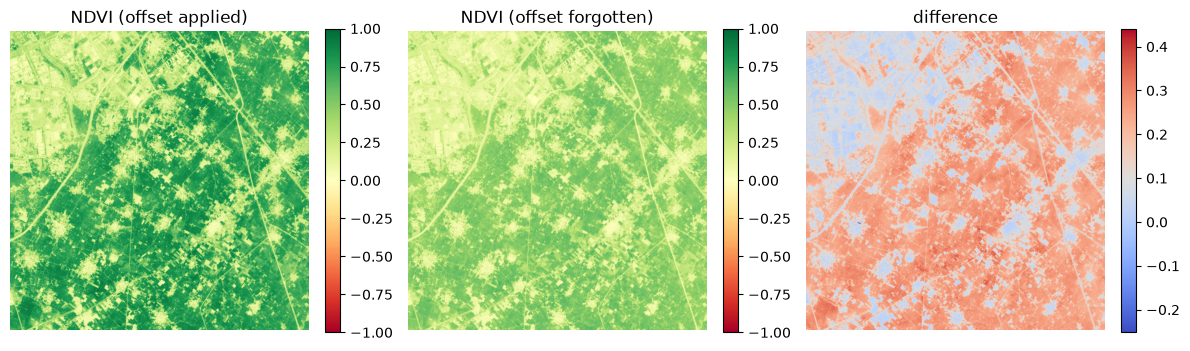

In [5]:
figure, axes = plt.subplots(1, 3)
for axis, array, title in (
    (axes[0], ndvi_correct, "NDVI (offset applied)"),
    (axes[1], ndvi_no_offset, "NDVI (offset forgotten)"),
    (axes[2], ndvi_correct - ndvi_no_offset, "difference"),
):
    image = axis.imshow(array, cmap="RdYlGn" if "difference" not in title else "coolwarm",
                        vmin=-1 if "difference" not in title else None,
                        vmax=1 if "difference" not in title else None)
    axis.set_title(title)
    axis.axis("off")
    figure.colorbar(image, ax=axis, fraction=0.046)
plt.tight_layout()


## 3. Quirk two — band resolutions differ inside one scene

B02/03/04/08 are 10 m; the red-edge and SWIR bands are 20 m; B01/09/10 are 60 m. Any index combining
across those needs resampling first, and rasterio will happily read two differently-shaped arrays that
then fail to broadcast — or worse, broadcast wrongly if one happens to be a factor of the other.


In [6]:
for name, path in bands.items():
    with rasterio.open(path) as source:
        print(f"{name:5s} {source.width}x{source.height}  {source.res[0]:.0f} m  {source.crs}")


B04   10980x10980  10 m  EPSG:32643
B08   10980x10980  10 m  EPSG:32643


## 4. Quirk three — L2A is not L1C, and mixing them is a change map of the atmosphere

L2A is surface reflectance, already atmospherically corrected. L1C is top-of-atmosphere. They differ most
where the atmosphere differs — haze, aerosol, water vapour — so a temporal pair with one of each produces
a confident change map of the weather. There is nothing in the pixel values that says which is which; the
product level is in the scene id, and this is the check worth doing before any pair is compared.


In [7]:
product_level = "L2A" if "MSIL2A" in scene.sample_id else "L1C" if "MSIL1C" in scene.sample_id else "unknown"
print(f"{scene.sample_id}\n  -> product level {product_level}")
assert product_level == "L2A", "this notebook assumes surface reflectance"


S2B_MSIL2A_20240319T052649_R105_T43RGM_20240319T094507
  -> product level L2A


## What this records back into the catalogue

The three quirks above are the ones written into `DatasetRecord.quirks` for `sentinel2-l2a`, so that a
caller sees the one-line version without opening this notebook. The measured band size — ~230 MB for a
single 10 m band as a COG, against published figures suggesting ~100 MB — is recorded there too, and is
why `aeris dataset fetch` takes `--asset`.
